# Alphard GCS Advice Viewer

Run **Runtime → Run all** in Colab to refresh the latest Alphard advisory slot from GCS, download the requested symbol report and charts, and render an operator-friendly view.

The notebook uses this contract:

```text
advice/latest.json                    # fixed pointer to latest processed slot
advice/<uid>/manifest.json            # all symbols processed in that slot
advice/<uid>/<SYMBOL>.json            # one full report per symbol
charts/<SYMBOL>/*.png                 # global + detail charts referenced by the report
```

In [25]:
# Install dependencies. Safe to rerun in Colab.
%pip -q install google-cloud-storage pandas pillow

In [26]:
# @title
# Configuration and authentication

from __future__ import annotations

from pathlib import Path
from typing import Any
import datetime as dt
import hashlib
import html
import json
import os

import pandas as pd
from IPython.display import HTML, Image, Markdown, display
from google.cloud import storage

# ---- Edit these if needed --------------------------------------------------
PROJECT_ID = os.environ.get("PROJECT_ID", "alphard3")
BUCKET_NAME = os.environ.get("BUCKET_NAME", "charts-alphard3")
LATEST_BLOB = os.environ.get("LATEST_BLOB", "advice/latest.json")
CACHE_DIR = Path(os.environ.get("ALPHARD_CACHE_DIR", "/content/alphard_advice_cache"))

# Set True when you want to redownload everything even if uid did not change.
FORCE_DOWNLOAD = False
# ---------------------------------------------------------------------------

try:
    from google.colab import auth  # type: ignore
    IN_COLAB = True
except Exception:
    auth = None
    IN_COLAB = False

if IN_COLAB and not os.environ.get("GOOGLE_APPLICATION_CREDENTIALS"):
    try:
        # Newer Colab supports project_id; older Colab does not.
        auth.authenticate_user(project_id=PROJECT_ID)  # type: ignore[arg-type]
    except TypeError:
        auth.authenticate_user()  # type: ignore[union-attr]

client = storage.Client(project=PROJECT_ID)
bucket = client.bucket(BUCKET_NAME)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project: {PROJECT_ID}")
print(f"Bucket:  gs://{BUCKET_NAME}")
print(f"Cache:   {CACHE_DIR}")

Project: alphard3
Bucket:  gs://charts-alphard3
Cache:   /content/alphard_advice_cache


In [27]:
# @title
# GCS, cache, and JSON helpers

def now_utc_iso() -> str:
    return dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds")


def gs_uri_to_bucket_blob(gs_uri: str) -> tuple[str, str]:
    if not gs_uri or not gs_uri.startswith("gs://"):
        raise ValueError(f"Expected gs:// URI, got: {gs_uri!r}")
    rest = gs_uri[5:]
    bucket_name, blob_name = rest.split("/", 1)
    return bucket_name, blob_name


def read_json_blob(bucket_name: str, blob_name: str) -> dict[str, Any]:
    blob = client.bucket(bucket_name).blob(blob_name)
    if not blob.exists():
        raise FileNotFoundError(f"Missing gs://{bucket_name}/{blob_name}")
    return json.loads(blob.download_as_text())


def read_json_gs_uri(gs_uri: str) -> dict[str, Any]:
    b, n = gs_uri_to_bucket_blob(gs_uri)
    return read_json_blob(b, n)


def load_local_json(path: Path, default: Any = None) -> Any:
    if not path.exists():
        return default
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return default


def save_local_json(path: Path, payload: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2, sort_keys=True), encoding="utf-8")


def stable_json_sha256(payload: Any) -> str:
    data = json.dumps(payload, ensure_ascii=False, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(data).hexdigest()


def download_blob_to_path(bucket_name: str, blob_name: str, local_path: Path, *, force: bool = False) -> Path:
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists() and not force:
        return local_path
    blob = client.bucket(bucket_name).blob(blob_name)
    if not blob.exists():
        raise FileNotFoundError(f"Missing gs://{bucket_name}/{blob_name}")
    blob.download_to_filename(str(local_path))
    return local_path


def download_gs_uri_to_path(gs_uri: str, local_path: Path, *, force: bool = False) -> Path:
    b, n = gs_uri_to_bucket_blob(gs_uri)
    return download_blob_to_path(b, n, local_path, force=force)


def download_json_gs_uri(gs_uri: str, local_path: Path, *, force: bool = False) -> dict[str, Any]:
    if local_path.exists() and not force:
        cached = load_local_json(local_path)
        if isinstance(cached, dict):
            return cached
    payload = read_json_gs_uri(gs_uri)
    save_local_json(local_path, payload)
    return payload


def safe_filename(value: str) -> str:
    return "".join(c if c.isalnum() or c in "._-" else "_" for c in value)


def find_manifest_result(manifest: dict[str, Any], symbol: str) -> dict[str, Any] | None:
    symbol = symbol.upper()
    for item in manifest.get("results", []):
        if str(item.get("symbol", "")).upper() == symbol:
            return item
    return None

In [28]:
# @title
# Refresh latest pointer and slot manifest.
# This cell always checks the remote latest pointer, then compares it with the
# local cached manifest to decide whether a full sync is needed.

remote_latest = read_json_blob(BUCKET_NAME, LATEST_BLOB)
remote_uid = remote_latest.get("uid")
remote_manifest_uri = remote_latest.get("manifest", {}).get("gcs_uri")

if not remote_uid:
    raise ValueError(f"Remote latest pointer has no uid: gs://{BUCKET_NAME}/{LATEST_BLOB}")
if not remote_manifest_uri:
    raise ValueError("Remote latest pointer has no manifest.gcs_uri")

local_latest_path = CACHE_DIR / "advice" / "latest.json"
local_manifest_path = CACHE_DIR / "advice" / str(remote_uid) / "manifest.json"
local_latest = load_local_json(local_latest_path, default={}) or {}
local_manifest = load_local_json(local_manifest_path, default=None)

local_uid = local_latest.get("uid")
local_manifest_uri = local_latest.get("manifest", {}).get("gcs_uri")
remote_latest_hash = stable_json_sha256(remote_latest)
local_latest_hash = stable_json_sha256(local_latest) if local_latest else None

SYNC_NEEDED = bool(
    FORCE_DOWNLOAD
    or local_uid != remote_uid
    or local_manifest_uri != remote_manifest_uri
    or local_latest_hash != remote_latest_hash
    or not local_manifest_path.exists()
    or not isinstance(local_manifest, dict)
)

if SYNC_NEEDED:
    MANIFEST = download_json_gs_uri(remote_manifest_uri, local_manifest_path, force=True)
    save_local_json(local_latest_path, remote_latest)
    sync_msg = "SYNCED from GCS"
else:
    MANIFEST = local_manifest
    sync_msg = "CACHE HIT: local manifest is already latest"

LATEST = remote_latest
ACTIVE_UID = int(remote_uid)

summary = {
    "run_at": now_utc_iso(),
    "sync": sync_msg,
    "uid": ACTIVE_UID,
    "timeframe": LATEST.get("timeframe"),
    "strategy": LATEST.get("strategy"),
    "processed_count": LATEST.get("processed_count"),
    "symbols_expected": LATEST.get("symbols_expected"),
    "latest_pointer": f"gs://{BUCKET_NAME}/{LATEST_BLOB}",
    "manifest": remote_manifest_uri,
    "local_manifest": str(local_manifest_path),
    "latest_sha256": remote_latest_hash[:16],
}

display(Markdown("## Latest slot"))
display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))

## Latest slot

,value
run_at,2026-06-26T13:38:15+00:00
sync,SYNCED from GCS
uid,202606261431
timeframe,M1
strategy,advisory_two_scale_strategy
processed_count,6
symbols_expected,"[USDCAD, EURGBP, GBPUSD, EURUSD, XAUUSD, XAGUSD]"
latest_pointer,gs://charts-alphard3/advice/latest.json
manifest,gs://charts-alphard3/advice/202606261431/manif...
local_manifest,/content/alphard_advice_cache/advice/202606261...


In [29]:
# @title
# Rendering helpers for operator view

STYLE = r'''
<style>
.alphard-wrap {font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif; color: #17202a;}
.alphard-card {border: 1px solid #d7dde8; border-radius: 12px; padding: 14px 16px; margin: 12px 0; background: #ffffff; box-shadow: 0 1px 3px rgba(0,0,0,.05);}
.alphard-title {font-size: 22px; font-weight: 750; margin: 0 0 8px 0;}
.alphard-subtitle {font-size: 14px; color: #5b6678; margin: 2px 0 12px 0;}
.alphard-grid {display: grid; grid-template-columns: repeat(auto-fit, minmax(170px, 1fr)); gap: 10px; margin: 10px 0;}
.alphard-metric {border: 1px solid #e1e7f0; border-radius: 10px; padding: 10px 12px; background: #f8fafc;}
.alphard-label {font-size: 11px; text-transform: uppercase; letter-spacing: .05em; color: #64748b; margin-bottom: 5px;}
.alphard-value {font-size: 16px; font-weight: 700; overflow-wrap: anywhere;}
.badge {display: inline-block; padding: 4px 9px; border-radius: 999px; font-weight: 750; font-size: 12px; border: 1px solid transparent;}
.badge-buy, .badge-ok {background: #dcfce7; color: #14532d; border-color: #86efac;}
.badge-sell, .badge-danger {background: #fee2e2; color: #7f1d1d; border-color: #fca5a5;}
.badge-hold, .badge-neutral {background: #f1f5f9; color: #334155; border-color: #cbd5e1;}
.badge-warn {background: #fef3c7; color: #78350f; border-color: #fcd34d;}
.badge-error {background: #ffedd5; color: #7c2d12; border-color: #fdba74;}
.side-buy {color: #166534; font-weight: 800;}
.side-sell {color: #991b1b; font-weight: 800;}
.side-hold {color: #475569; font-weight: 800;}
.error-box {border-left: 5px solid #f97316; background: #fff7ed; padding: 10px 12px; border-radius: 8px; margin: 10px 0;}
.good-box {border-left: 5px solid #22c55e; background: #f0fdf4; padding: 10px 12px; border-radius: 8px; margin: 10px 0;}
.warn-box {border-left: 5px solid #eab308; background: #fefce8; padding: 10px 12px; border-radius: 8px; margin: 10px 0;}
.alphard-table {border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 8px;}
.alphard-table th {background: #eef2ff; color: #1e293b; text-align: left; padding: 8px; border: 1px solid #dbe3f0; vertical-align: top;}
.alphard-table td {padding: 8px; border: 1px solid #e5e7eb; vertical-align: top;}
.alphard-table tr:nth-child(even) td {background: #fafafa;}
.mono {font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;}
.json-pre {white-space: pre-wrap; overflow-x: auto; font-size: 12px; max-height: 620px; background: #0f172a; color: #e2e8f0; padding: 12px; border-radius: 10px;}
.small {font-size: 12px; color: #64748b;}
.confbar {height: 9px; border-radius: 999px; background: #e2e8f0; overflow: hidden; margin-top: 6px;}
.confbar > div {height: 100%; background: linear-gradient(90deg, #f97316, #eab308, #22c55e);}
.chart-title {font-size: 20px; font-weight: 750; margin: 18px 0 6px 0;}
</style>
'''

display(HTML(STYLE))


def e(value: Any) -> str:
    return html.escape("" if value is None else str(value))


def pct(value: Any) -> str:
    try:
        v = float(value)
        if v <= 1.0:
            v *= 100
        return f"{v:.0f}%"
    except Exception:
        return "—"


def price(value: Any) -> str:
    try:
        return f"{float(value):.5f}"
    except Exception:
        return e(value) if value is not None else "—"


def compact(value: Any, *, max_len: int = 220) -> str:
    if value is None:
        return "—"
    if isinstance(value, float):
        return price(value)
    if isinstance(value, (list, tuple)):
        return ", ".join(compact(x, max_len=80) for x in value) if value else "—"
    if isinstance(value, dict):
        return "<br>".join(f"<b>{e(k)}</b>: {compact(v, max_len=100)}" for k, v in value.items()) if value else "—"
    text = str(value)
    if len(text) > max_len:
        text = text[: max_len - 1] + "…"
    return e(text)


def badge(value: Any) -> str:
    text = str(value or "UNKNOWN").upper()
    cls = "neutral"
    if text in {"BUY", "LONG", "APPROVED", "PROCESSED", "OK"}:
        cls = "buy"
    elif text in {"SELL", "SHORT"}:
        cls = "sell"
    elif text in {"ERROR", "FAILED", "REJECTED"}:
        cls = "error"
    elif text in {"WARN", "WARNING", "PARTIAL"}:
        cls = "warn"
    elif text in {"HOLD", "NO_TRADE", "NONE"}:
        cls = "hold"
    return f'<span class="badge badge-{cls}">{e(text)}</span>'


def side_text(side: Any) -> str:
    s = str(side or "").lower()
    cls = "side-hold"
    if s == "buy":
        cls = "side-buy"
    elif s == "sell":
        cls = "side-sell"
    return f'<span class="{cls}">{e(side or "—")}</span>'


def metric(label: str, value_html: str) -> str:
    return f'<div class="alphard-metric"><div class="alphard-label">{e(label)}</div><div class="alphard-value">{value_html}</div></div>'


def confidence_html(value: Any) -> str:
    try:
        v = float(value)
        pct_value = max(0, min(100, v * 100 if v <= 1 else v))
        return f'{pct_value:.0f}%<div class="confbar"><div style="width:{pct_value:.0f}%"></div></div>'
    except Exception:
        return "—"


def dict_rows(mapping: dict[str, Any], *, keys: list[str] | None = None) -> str:
    if not mapping:
        return '<tr><td colspan="2" class="small">No data</td></tr>'
    items = [(k, mapping.get(k)) for k in keys] if keys else list(mapping.items())
    rows = []
    for k, v in items:
        if v is None or v == {} or v == []:
            continue
        rows.append(f"<tr><th>{e(k)}</th><td>{compact(v, max_len=520)}</td></tr>")
    return "".join(rows) or '<tr><td colspan="2" class="small">No data</td></tr>'


def render_key_tables(report: dict[str, Any]) -> str:
    rec = report.get("recommendation", {}) or {}
    mc = rec.get("market_classification", {}) or {}
    dyn = rec.get("latest_dynamics", {}) or {}
    levels = rec.get("levels", {}) or report.get("visible_levels", {}) or {}
    mc_keys = [
        "long_term_regime", "regime_confidence", "global_bias", "global_structure",
        "global_range_or_channel", "key_maximum", "key_minimum", "current_location",
    ]
    dyn_keys = [
        "state", "preferred_direction", "entry_quality", "why_now_or_why_not",
        "nearest_supports", "nearest_resistances",
    ]
    return f'''
    <div class="alphard-grid">
      <div class="alphard-card">
        <div class="alphard-title">Market classification</div>
        <table class="alphard-table">{dict_rows(mc, keys=mc_keys)}</table>
      </div>
      <div class="alphard-card">
        <div class="alphard-title">Latest dynamics</div>
        <table class="alphard-table">{dict_rows(dyn, keys=dyn_keys)}</table>
      </div>
    </div>
    <div class="alphard-card">
      <div class="alphard-title">Levels</div>
      <table class="alphard-table">{dict_rows(levels)}</table>
    </div>
    '''


def entry_zone_html(zone: Any) -> str:
    if isinstance(zone, dict):
        return f"{price(zone.get('from'))} → {price(zone.get('to'))}"
    return compact(zone)


def render_order_plan(report: dict[str, Any]) -> str:
    rec = report.get("recommendation", {}) or {}
    plan = rec.get("action_plan", {}) or {}
    legs = plan.get("order_plan", []) or []
    if not legs:
        return '''
        <div class="alphard-card">
          <div class="alphard-title">Action plan</div>
          <div class="warn-box"><b>No executable legs found.</b> Check recommendation status and parser/model error below.</div>
        </div>
        '''
    rows = []
    for leg in legs:
        rows.append('''
        <tr>
          <td class="mono">{leg_id}</td>
          <td>{side}</td>
          <td>{kind}</td>
          <td>{alloc}</td>
          <td>{entry}</td>
          <td>{sl}</td>
          <td>{tp}</td>
          <td>{trigger}</td>
          <td>{invalid}</td>
          <td>{rationale}</td>
        </tr>
        '''.format(
            leg_id=e(leg.get("leg_id", "—")),
            side=side_text(leg.get("side")),
            kind=e(leg.get("order_kind", "—")),
            alloc=pct(leg.get("allocation_pct")),
            entry=entry_zone_html(leg.get("entry_zone")),
            sl=price(leg.get("stop_loss")),
            tp=price(leg.get("take_profit")),
            trigger=compact(leg.get("trigger"), max_len=260),
            invalid=compact(leg.get("invalid_if"), max_len=260),
            rationale=compact(leg.get("rationale"), max_len=260),
        ))
    summary_rows = dict_rows(plan, keys=[
        "recommendation", "total_allocation_pct", "risk_level", "primary_stop_loss",
        "primary_take_profit", "scale_out_targets", "do_not_add_beyond",
    ])
    return f'''
    <div class="alphard-card">
      <div class="alphard-title">Action plan</div>
      <table class="alphard-table">{summary_rows}</table>
      <table class="alphard-table">
        <thead>
          <tr>
            <th>Leg</th><th>Side</th><th>Kind</th><th>Alloc</th><th>Entry zone</th>
            <th>SL</th><th>TP</th><th>Trigger</th><th>Invalid if</th><th>Rationale</th>
          </tr>
        </thead>
        <tbody>{''.join(rows)}</tbody>
      </table>
    </div>
    '''


def render_diagnostics(report: dict[str, Any]) -> str:
    rec = report.get("recommendation", {}) or {}
    metrics = report.get("llm_metrics", {}) or {}
    response = metrics.get("response_summary", {}) or {}
    raw = rec.get("raw_text") or ""
    error = rec.get("error")
    finish_reason = response.get("finish_reason")
    if error:
        box = f'<div class="error-box"><b>Parser/model error:</b> {compact(error, max_len=1200)}</div>'
    elif finish_reason == "length":
        box = '<div class="warn-box"><b>Warning:</b> Model response stopped because of length. Validate that JSON/action plan is complete.</div>'
    else:
        box = '<div class="good-box"><b>Report parsed successfully.</b></div>'
    diag = {
        "finish_reason": finish_reason,
        "content_chars": response.get("content_chars"),
        "completion_tokens": metrics.get("completion_tokens"),
        "prompt_tokens": metrics.get("prompt_tokens"),
        "total_tokens": metrics.get("total_tokens"),
        "latency_ms": metrics.get("latency_ms"),
        "model": metrics.get("model"),
        "provider": metrics.get("provider"),
        "request_images": metrics.get("request_summary", {}).get("images"),
    }
    raw_preview = e(raw[-2500:] if raw else "")
    raw_block = ""
    if raw:
        raw_block = f'''
        <details>
          <summary><b>Raw model text tail</b> — useful when recommendation is ERROR</summary>
          <pre class="json-pre">{raw_preview}</pre>
        </details>
        '''
    report_json = e(json.dumps(report, ensure_ascii=False, indent=2, default=str))
    return f'''
    <div class="alphard-card">
      <div class="alphard-title">Diagnostics</div>
      {box}
      <table class="alphard-table">{dict_rows(diag)}</table>
      {raw_block}
      <details>
        <summary><b>Full report JSON</b></summary>
        <pre class="json-pre">{report_json}</pre>
      </details>
    </div>
    '''


def render_report_html(report: dict[str, Any], result: dict[str, Any] | None = None) -> str:
    result = result or {}
    rec = report.get("recommendation", {}) or {}
    plan = rec.get("action_plan", {}) or {}
    current = report.get("current_candle", {}) or {}
    status = rec.get("status") or result.get("recommendation") or "UNKNOWN"
    action = plan.get("recommendation") or result.get("recommendation") or rec.get("status")
    stop_tp = f"{price(plan.get('primary_stop_loss'))} / {price(plan.get('primary_take_profit'))}"
    return f'''
    <div class="alphard-wrap">
      <div class="alphard-card">
        <div class="alphard-title">{e(report.get('symbol', result.get('symbol', 'UNKNOWN')))} advisory report</div>
        <div class="alphard-subtitle">
          uid <span class="mono">{e(report.get('uid', result.get('uid', '—')))}</span> ·
          created {e(report.get('created_at', '—'))} ·
          candle {e(current.get('time_iso', '—'))}
        </div>
        <div class="alphard-grid">
          {metric('Status', badge(status))}
          {metric('Action', badge(action))}
          {metric('Confidence', confidence_html(rec.get('confidence', result.get('confidence'))))}
          {metric('Risk level', badge(plan.get('risk_level', '—')))}
          {metric('Allocation', pct(plan.get('total_allocation_pct')))}
          {metric('Stop / Take profit', stop_tp)}
        </div>
      </div>
      {render_order_plan(report)}
      {render_key_tables(report)}
      <!-- {render_diagnostics(report)} -->
    </div>
    '''


def display_chart_file(path: Path, title: str, *, width: int) -> None:
    display(HTML(f'<div class="chart-title">{e(title)}</div><div class="small mono">{e(str(path))}</div>'))
    display(Image(filename=str(path), width=width))

In [30]:
# @title
# === Symbol processor cell: copy-paste this whole cell for each symbol ===
# Change only SYMBOL. Everything else is intentionally self-contained.


def process_symbol(symbol: str) -> dict[str, Any]:
    symbol = symbol.upper().strip()
    if not symbol:
        raise ValueError("SYMBOL is empty")

    result = find_manifest_result(MANIFEST, symbol)
    if not result:
        available = [item.get("symbol") for item in MANIFEST.get("results", [])]
        raise ValueError(f"{symbol} not found in manifest uid={ACTIVE_UID}. Available: {available}")

    symbol_dir = CACHE_DIR / "advice" / str(ACTIVE_UID) / safe_filename(symbol)
    symbol_dir.mkdir(parents=True, exist_ok=True)

    advice_ref = (
        result.get("artifact", {})
        .get("advice", {})
        .get("gcs_uri")
    ) or f"gs://{BUCKET_NAME}/advice/{ACTIVE_UID}/{symbol}.json"

    report_path = symbol_dir / f"{symbol}_report_{ACTIVE_UID}.json"
    report = download_json_gs_uri(advice_ref, report_path, force=FORCE_DOWNLOAD or SYNC_NEEDED)

    chart_refs = report.get("chart_refs") or result.get("artifact", {}).get("charts", {})
    global_ref = (chart_refs.get("global") or {}).get("gcs_uri")
    detail_ref = (chart_refs.get("detail") or {}).get("gcs_uri")

    if not global_ref or not detail_ref:
        raise ValueError(f"Report has no chart_refs.global/detail.gcs_uri for {symbol}")

    global_path = download_gs_uri_to_path(
        global_ref,
        symbol_dir / f"{symbol}_global_{ACTIVE_UID}.png",
        force=FORCE_DOWNLOAD or SYNC_NEEDED,
    )
    detail_path = download_gs_uri_to_path(
        detail_ref,
        symbol_dir / f"{symbol}_detail_{ACTIVE_UID}.png",
        force=FORCE_DOWNLOAD or SYNC_NEEDED,
    )

    rec = report.get("recommendation", {}) or {}
    advice_local_html = f'<span class="mono">{html.escape(str(report_path))}</span>'
    gcs_advice_html = f'<span class="mono">{html.escape(advice_ref)}</span>'
    sync_html = (
        f'<div class="alphard-card"><div class="alphard-title">{html.escape(symbol)} · local sync</div>'
        f'<div class="alphard-grid">'
        f'{metric("Manifest result", badge(result.get("status", "PROCESSED")))}'
        f'{metric("Recommendation", badge(rec.get("status") or result.get("recommendation")))}'
        f'{metric("Advice JSON", advice_local_html)}'
        f'{metric("GCS advice", gcs_advice_html)}'
        f'</div></div>'
    )
    display(HTML(sync_html))

    global_bars = report.get("chart_windows", {}).get("global_bars", "global")
    detail_bars = report.get("chart_windows", {}).get("detail_bars", "detail")
    #display_chart_file(global_path, f"{symbol} global context · {global_bars} bars", width=1400)
    #display_chart_file(detail_path, f"{symbol} latest dynamics · {detail_bars} bars", width=1050)

    #display(HTML(render_report_html(report, result)))
    return report, result, global_path, detail_path

def show_global_path(report, path, symbol):
    global_bars = report.get("chart_windows", {}).get("global_bars", "global")
    display_chart_file(path, f"{symbol} global context · {global_bars} bars", width=1300)

def show_detail_path(report, path, symbol):
    detail_bars = report.get("chart_windows", {}).get("detail_bars", "detail")
    display_chart_file(path, f"{symbol} latest dynamics · {detail_bars} bars", width=800)



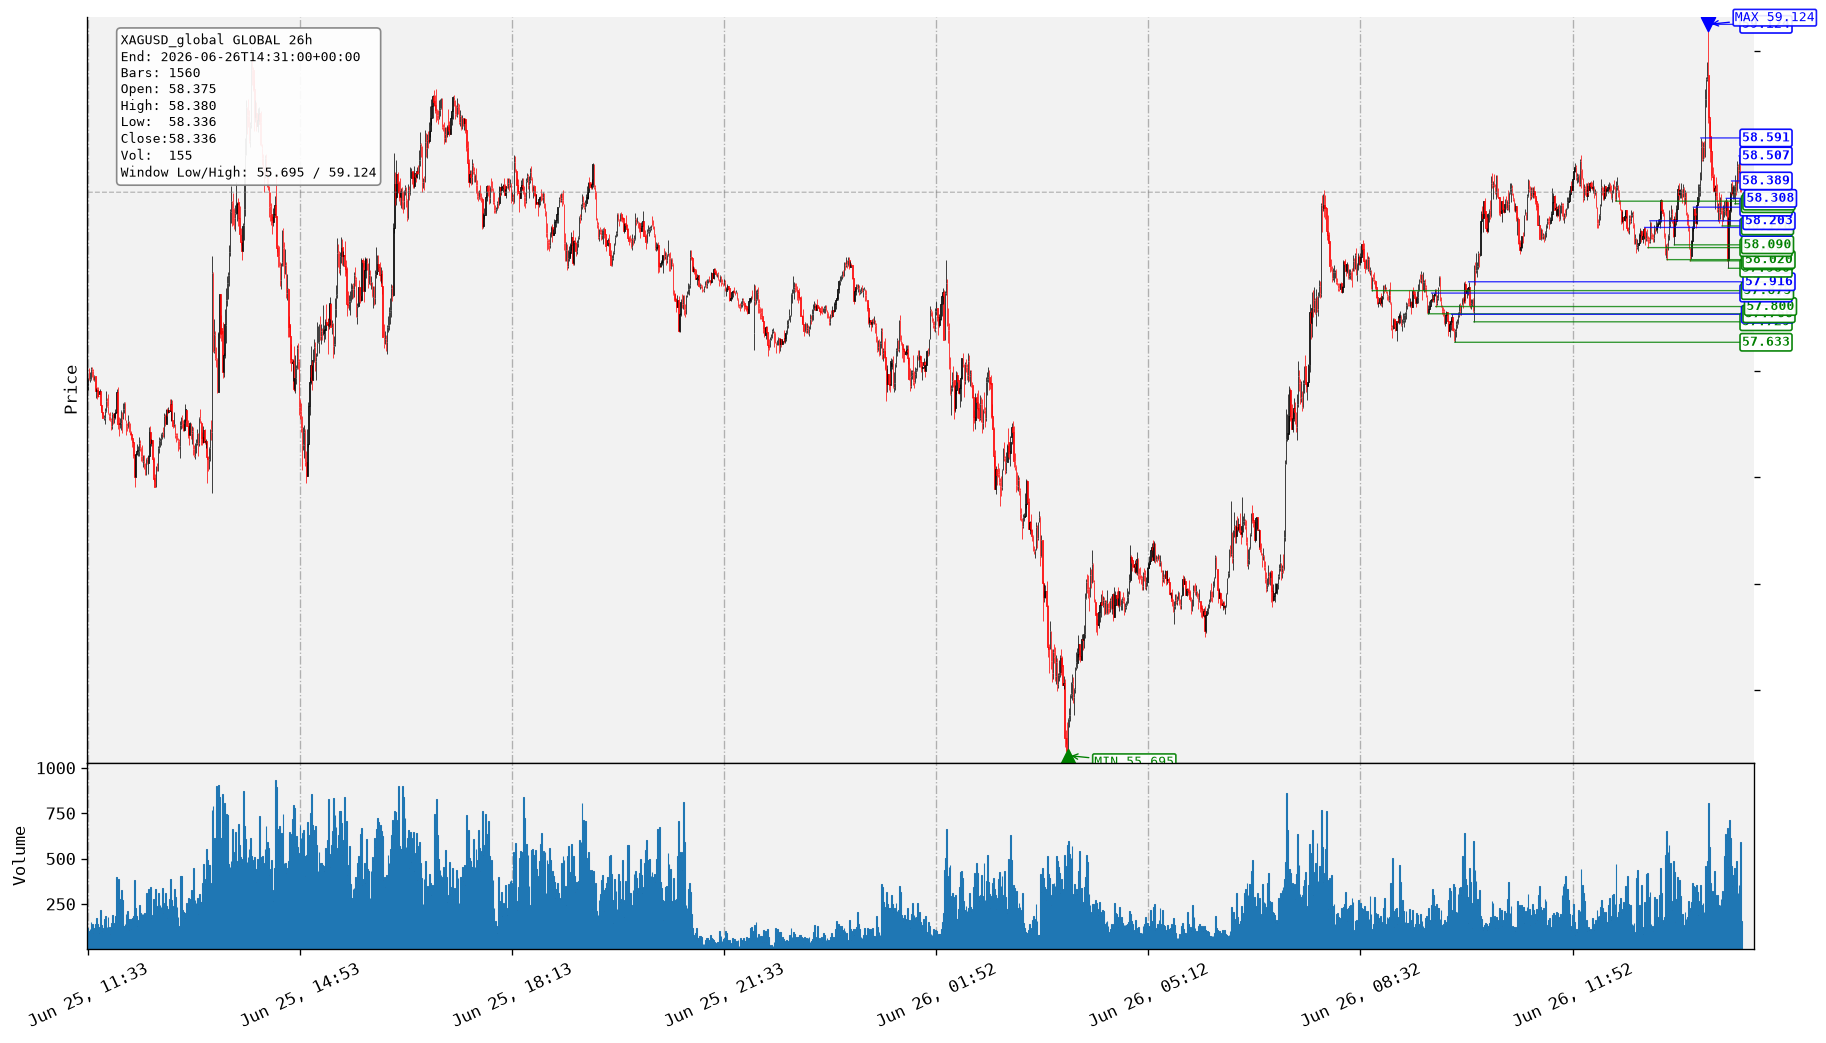

In [31]:
report, result, global_path, detail_path = process_symbol("XAGUSD")
show_global_path(report, global_path, "XAGUSD")


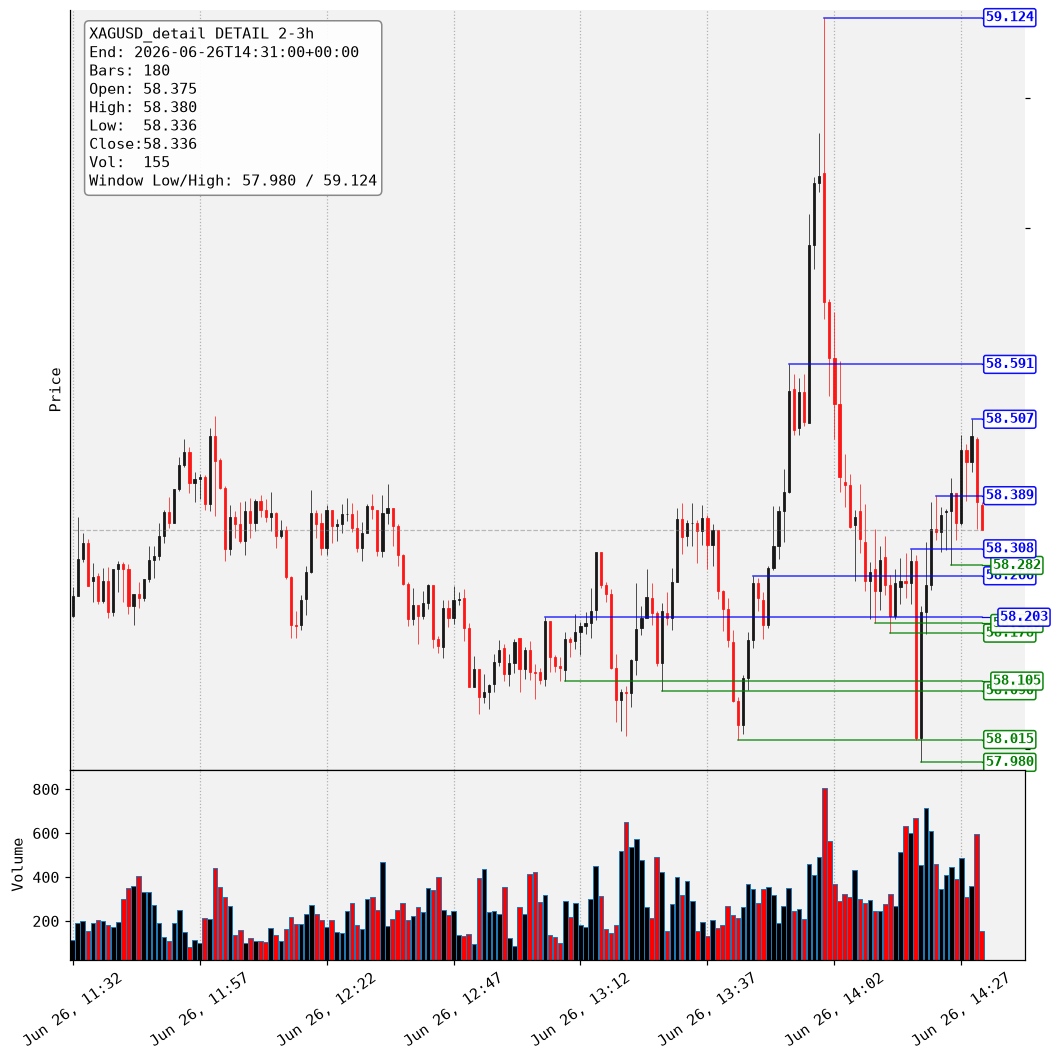

In [32]:
show_detail_path(report, detail_path, "XAGUSD")

In [33]:
display(HTML(render_report_html(report, result)))

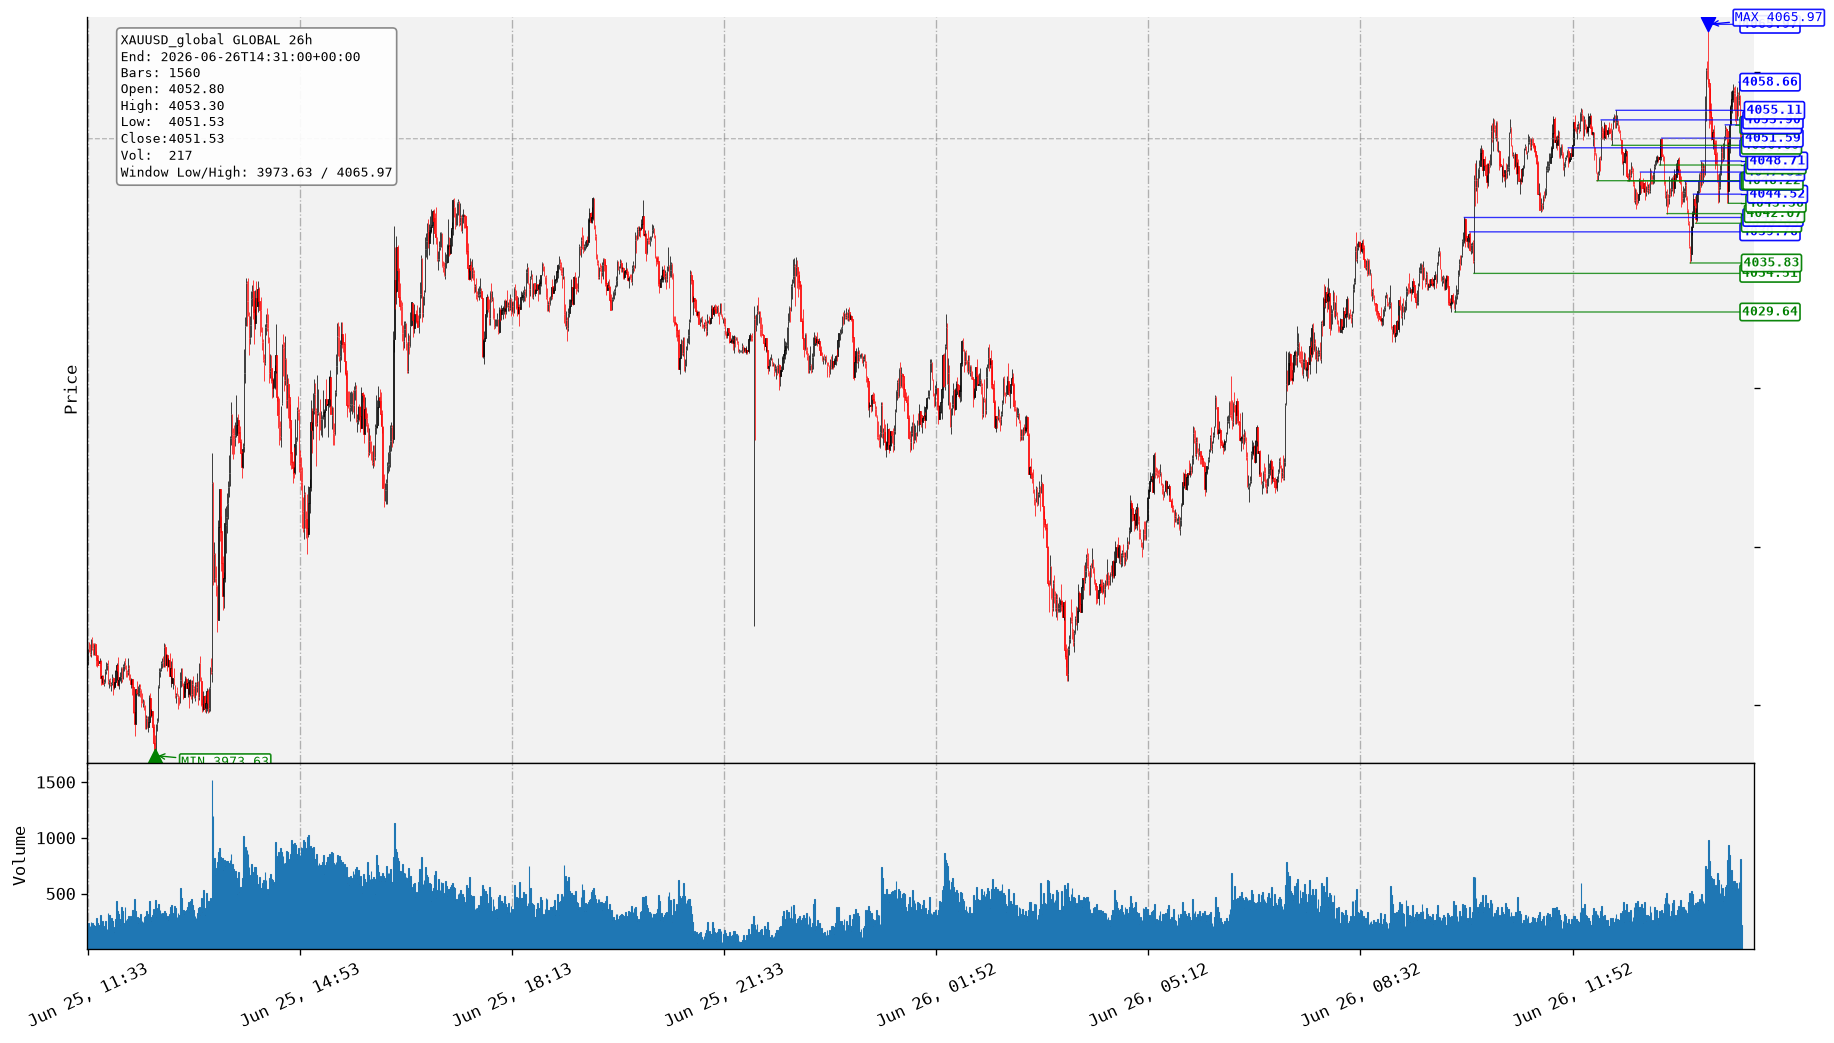

In [34]:
report, result, global_path, detail_path = process_symbol("XAUUSD")
show_global_path(report, global_path, "XAUUSD")

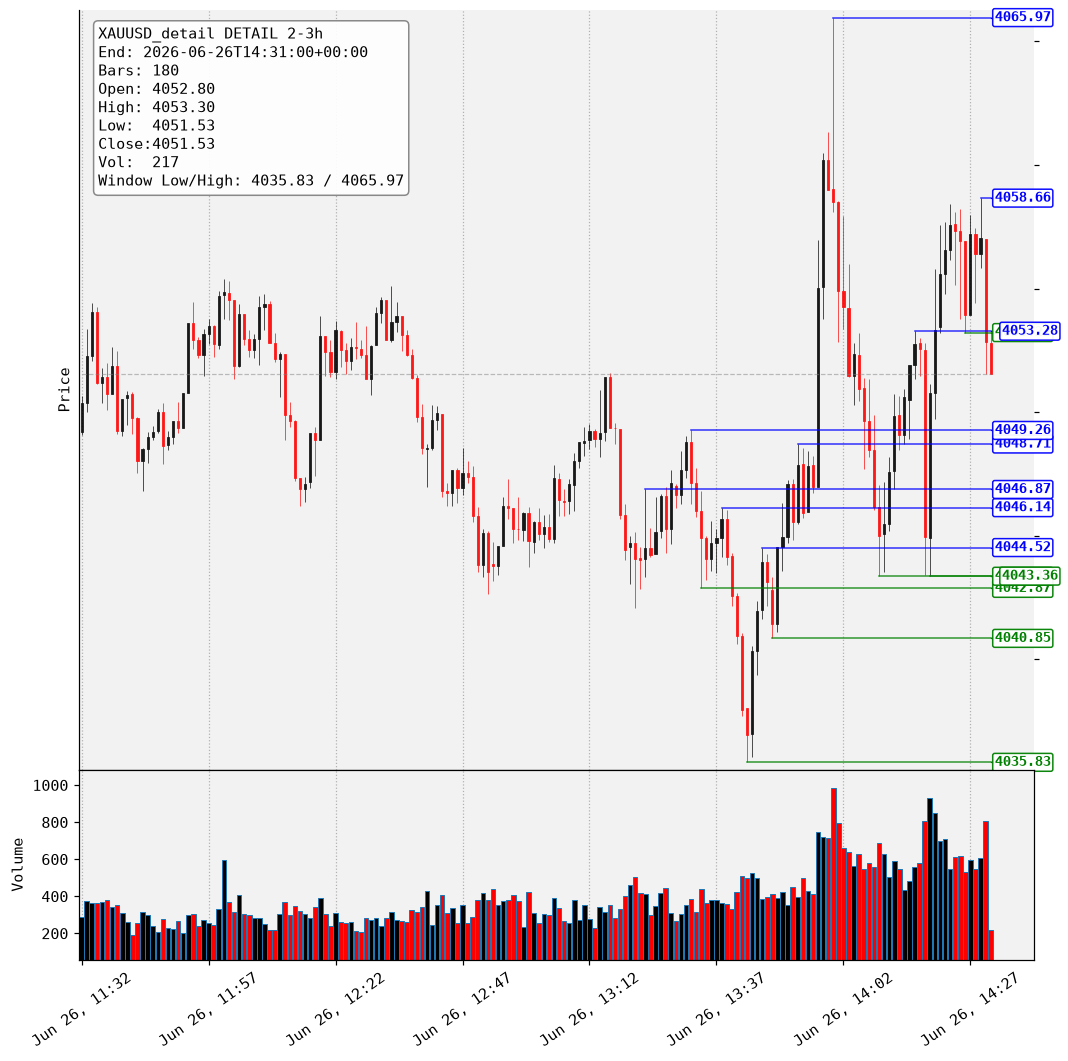

In [35]:
show_detail_path(report, detail_path, "XAUUSD")

In [36]:
display(HTML(render_report_html(report, result)))

long_term_regime,bull_trend
regime_confidence,0.80000
global_bias,buy_only
global_structure,"Strong uptrend over the last 26 hours, with price making higher highs and higher lows, currently pulling back from the period's absolute maximum."
global_range_or_channel,"description: The market is in a trend, not a defined channel or range.lower: —mid: —upper: —"
key_maximum,"meaning: Blow-off top and absolute high of the 26-hour period, followed by a sharp rejection.price: 4066.00000"
key_minimum,meaning: Starting point of the major bullish leg.price: 3973.60000
current_location,upper_half
state,sweep_reversal
preferred_direction,neutral
entry_quality,poor


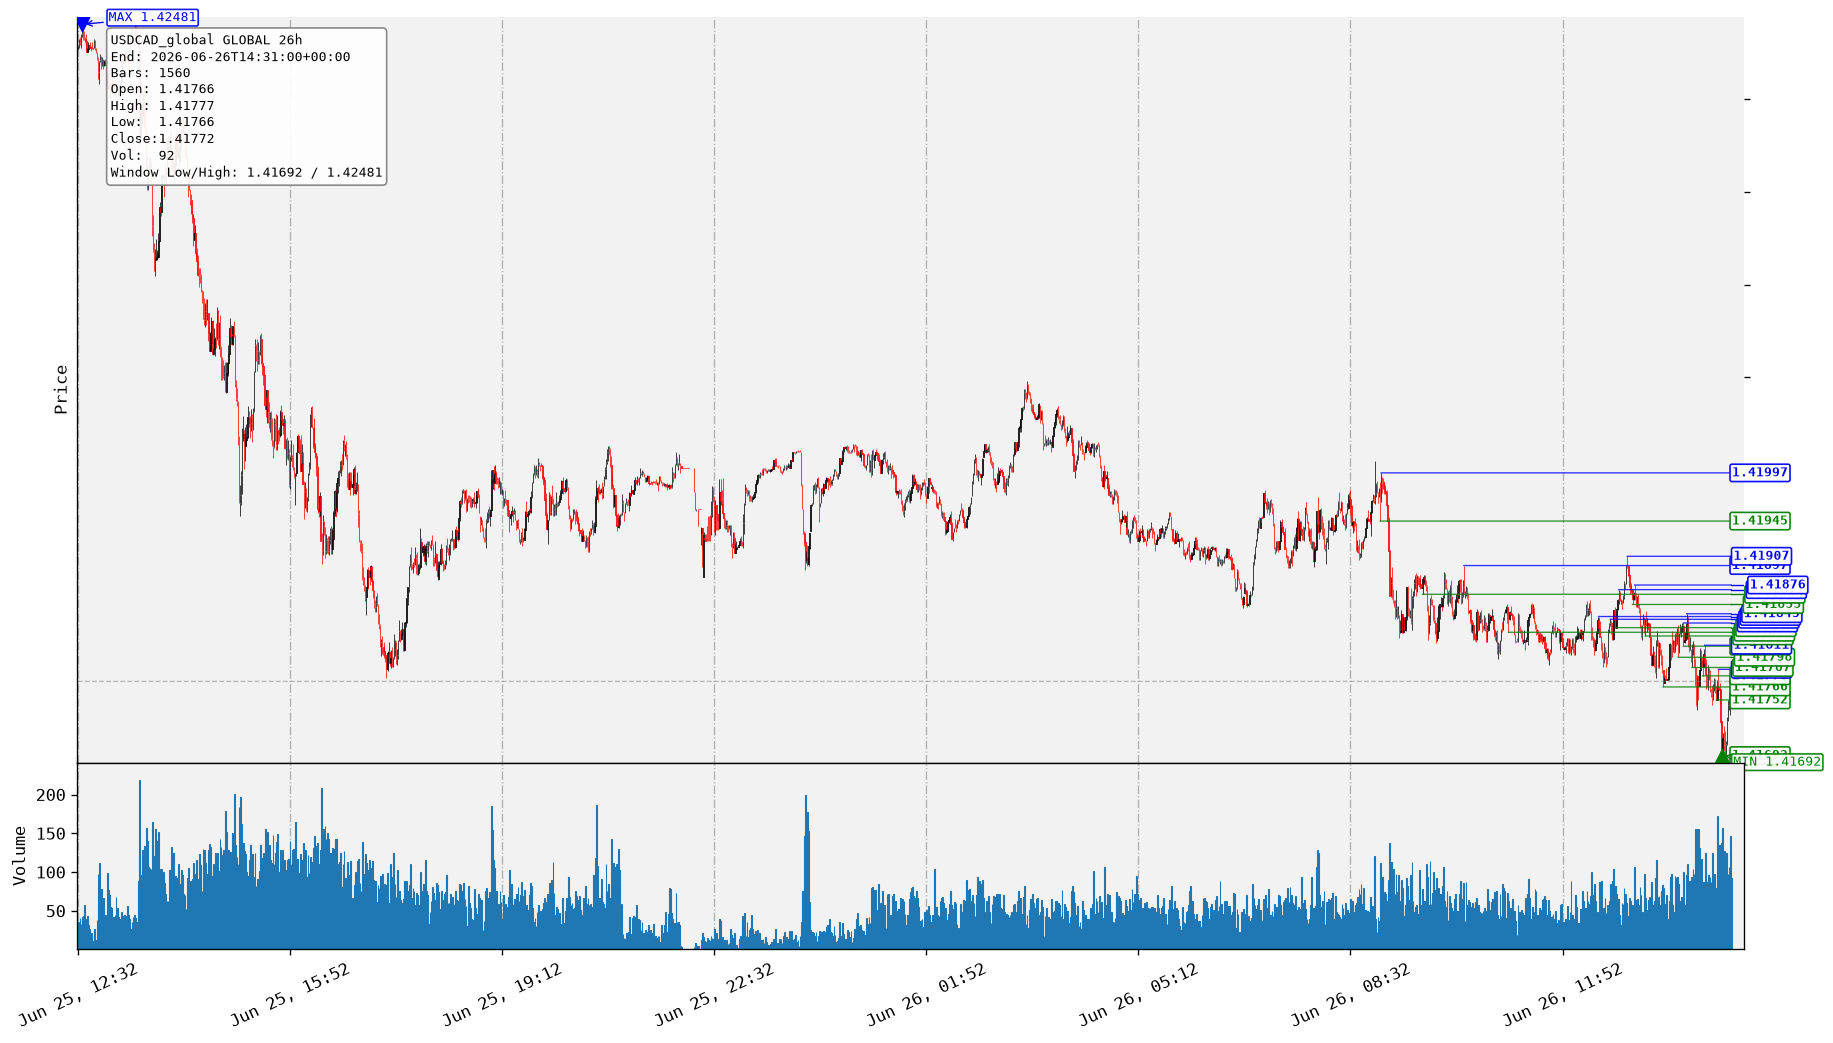

In [37]:
report, result, global_path, detail_path = process_symbol("USDCAD")
show_global_path(report, global_path, "USDCAD")

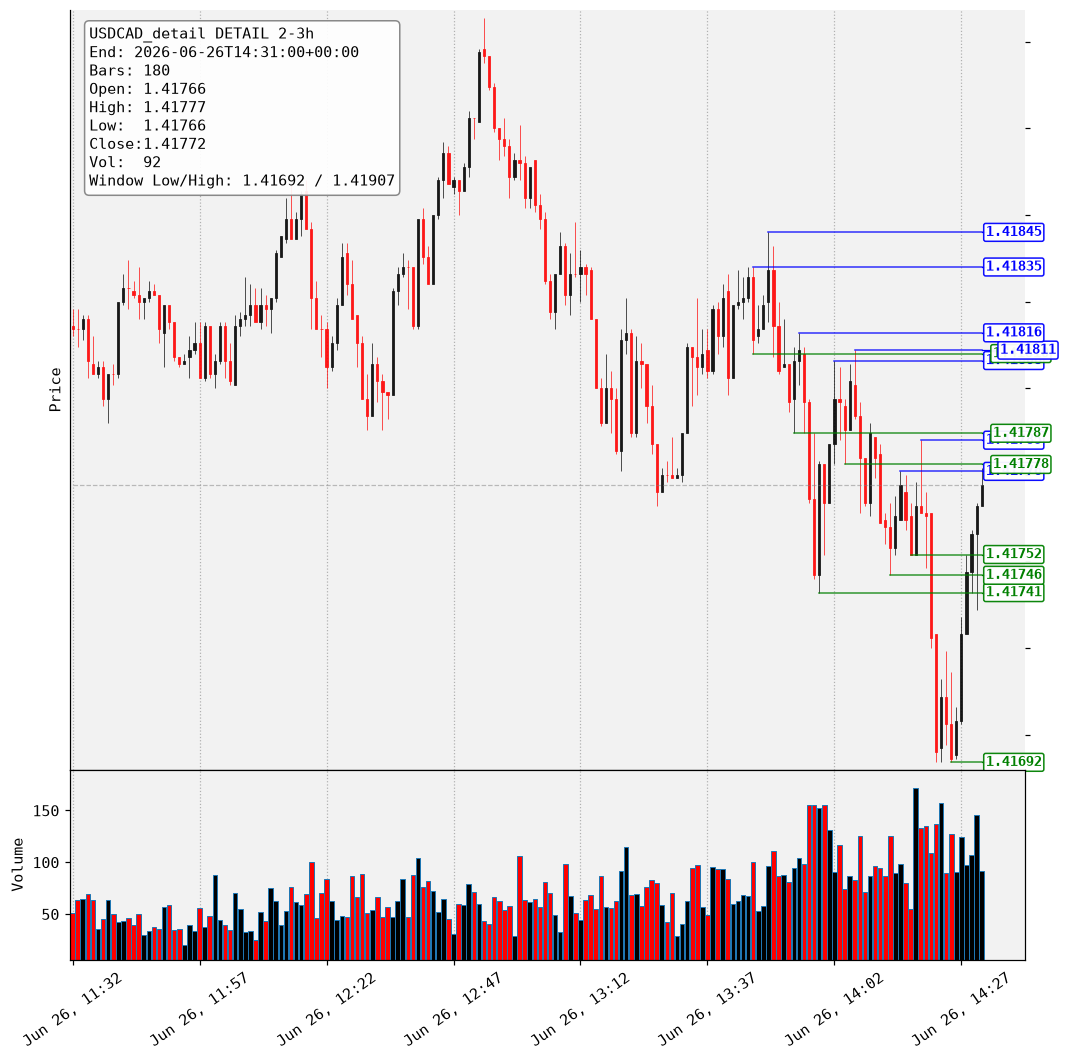

In [38]:
show_detail_path(report, detail_path, "USDCAD")

In [39]:
display(HTML(render_report_html(report, result)))

long_term_regime,bear_trend
regime_confidence,0.80000
global_bias,sell_only
global_structure,"Strong initial sell-off from the 26-hour high, followed by a persistent grinding descent with a series of lower highs and lower lows."
global_range_or_channel,description: This represents the full price range of the last 26 hours.lower: 1.41690mid: 1.42085upper: 1.42480
key_maximum,meaning: Peak of the 26-hour window and the starting point of the current downtrend.price: 1.42480
key_minimum,"meaning: The low of the 26-hour window, which was just established and is the current key support.price: 1.41690"
current_location,bottom
state,testing_support
preferred_direction,sell
entry_quality,poor


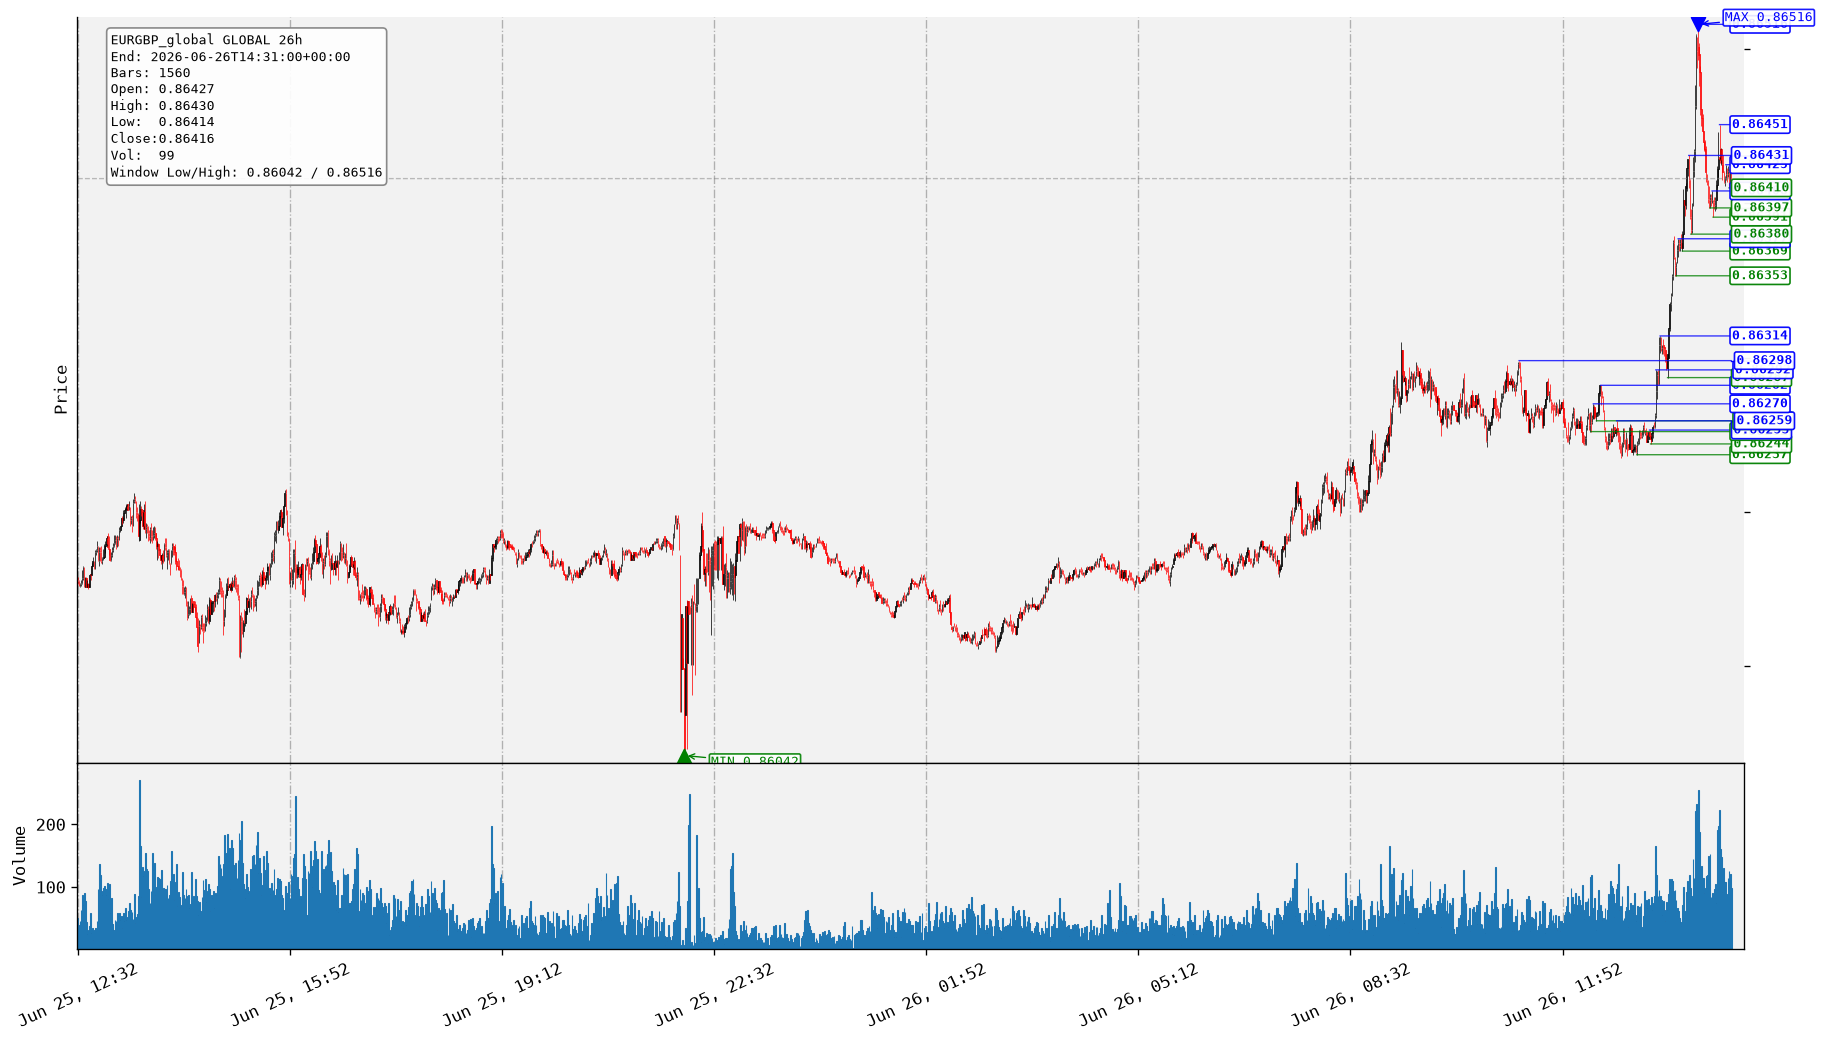

In [40]:
report, result, global_path, detail_path = process_symbol("EURGBP")
show_global_path(report, global_path, "EURGBP")

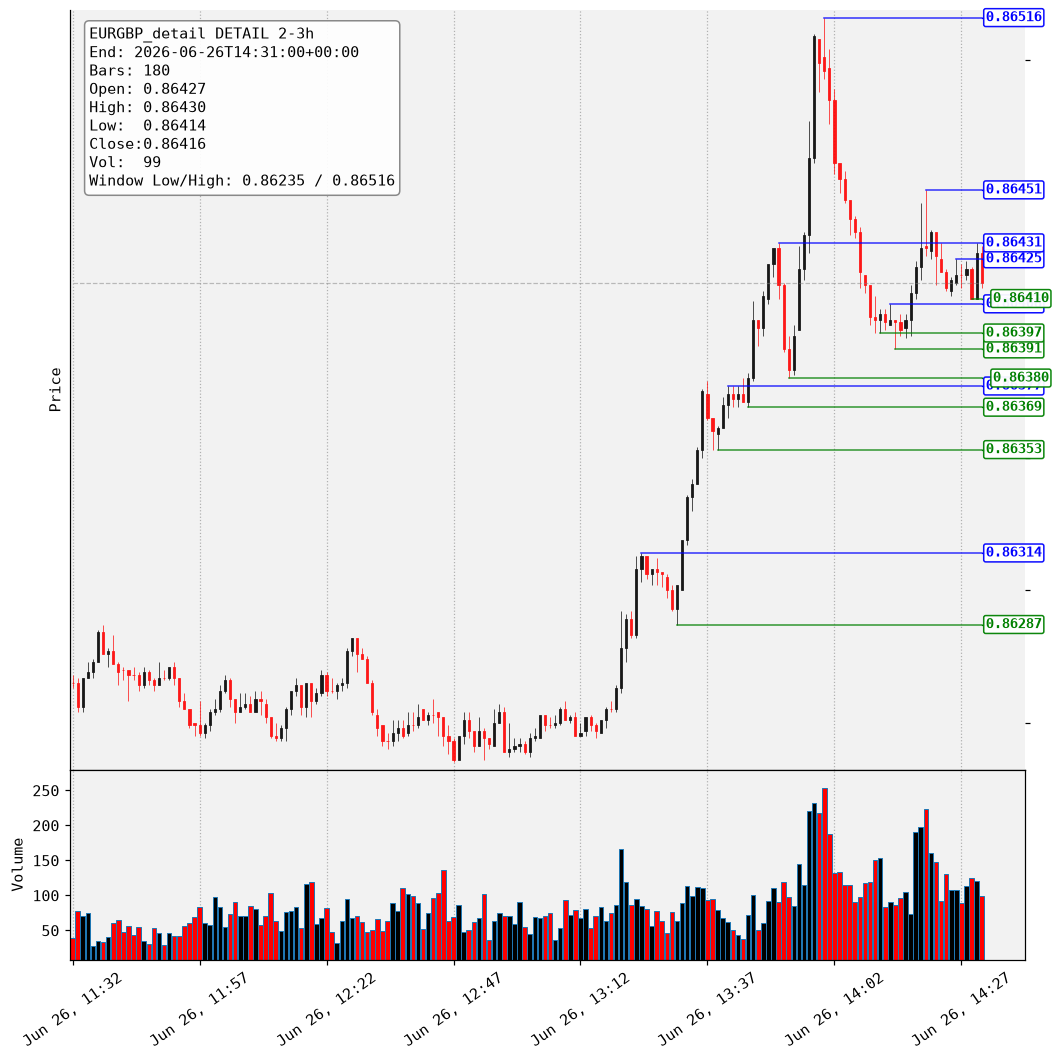

In [41]:
show_detail_path(report, detail_path, "EURGBP")

In [42]:
display(HTML(render_report_html(report, result)))

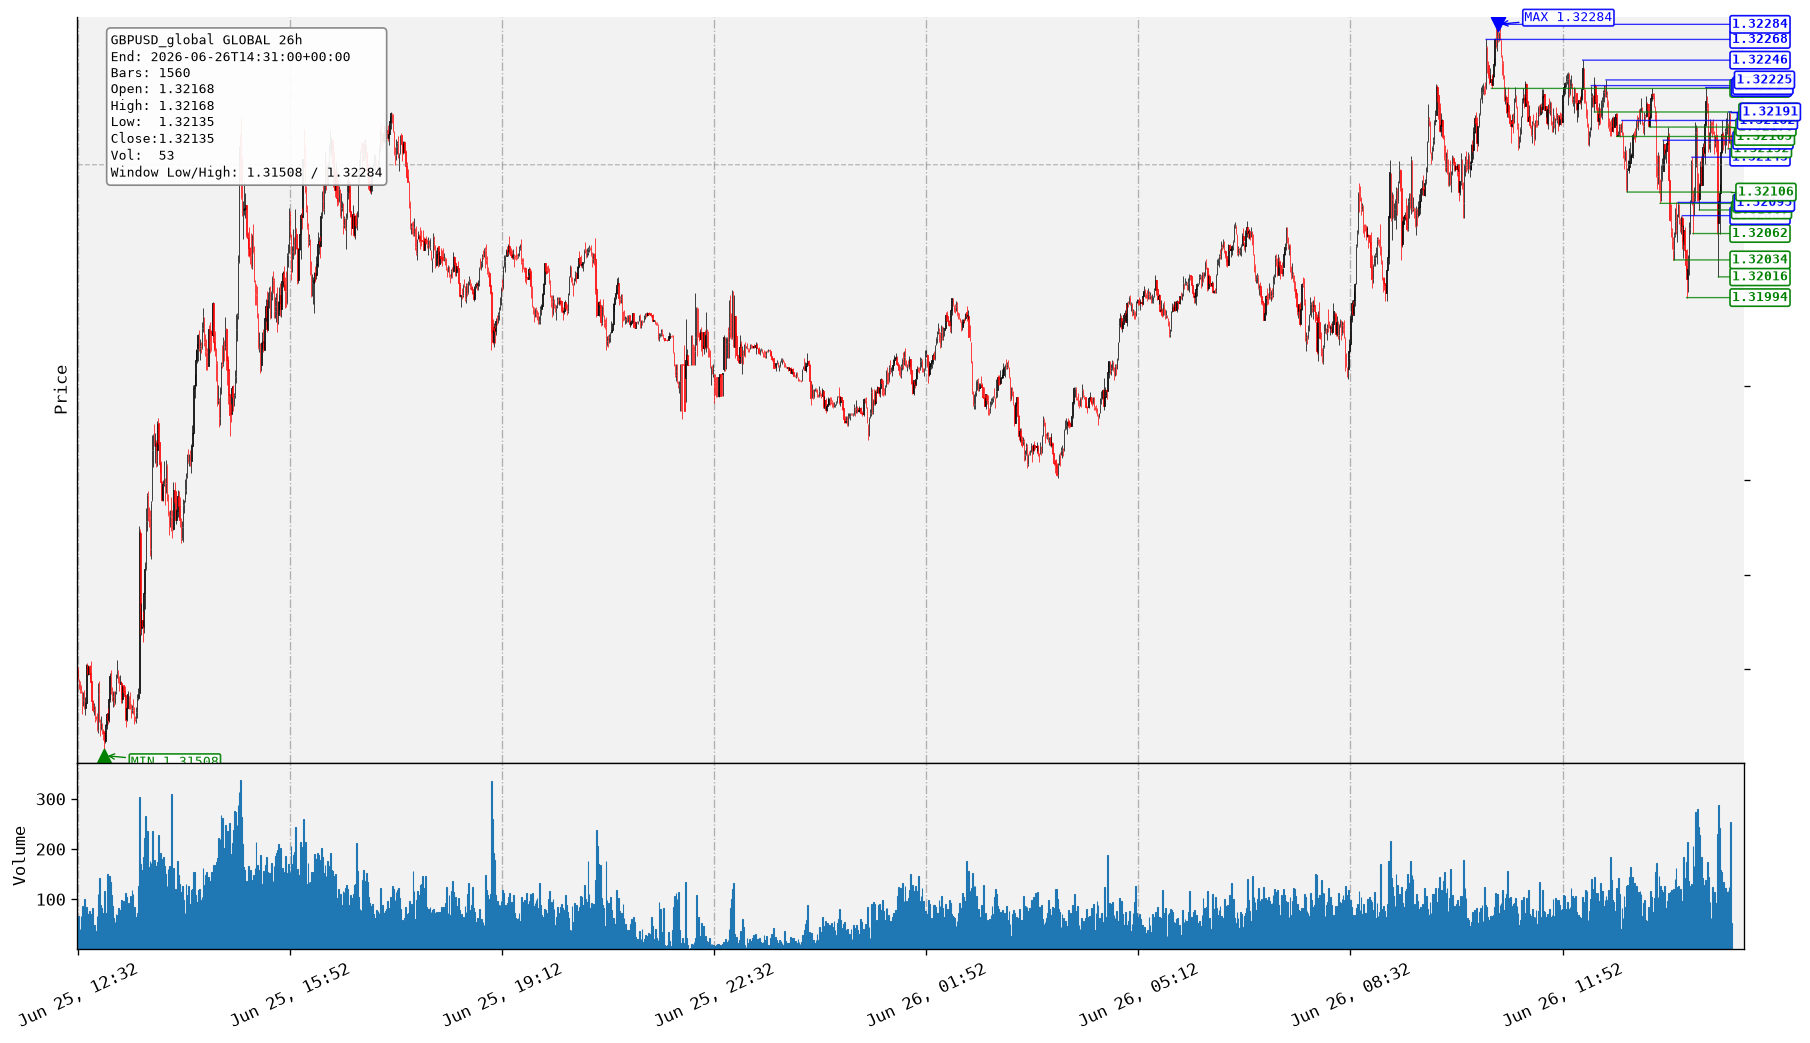

In [43]:
report, result, global_path, detail_path = process_symbol("GBPUSD")
show_global_path(report, global_path, "GBPUSD")

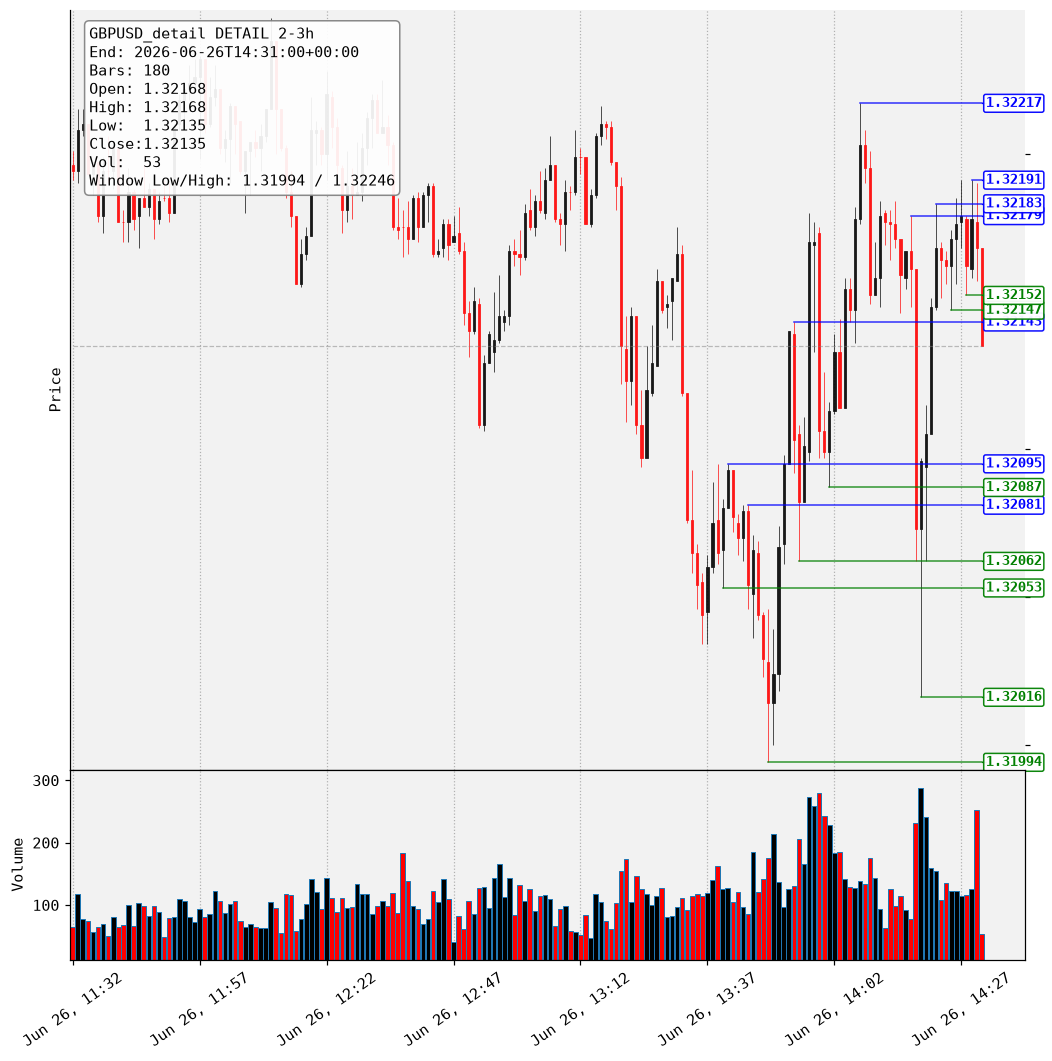

In [44]:
show_detail_path(report, detail_path, "GBPUSD")

In [45]:
display(HTML(render_report_html(report, result)))

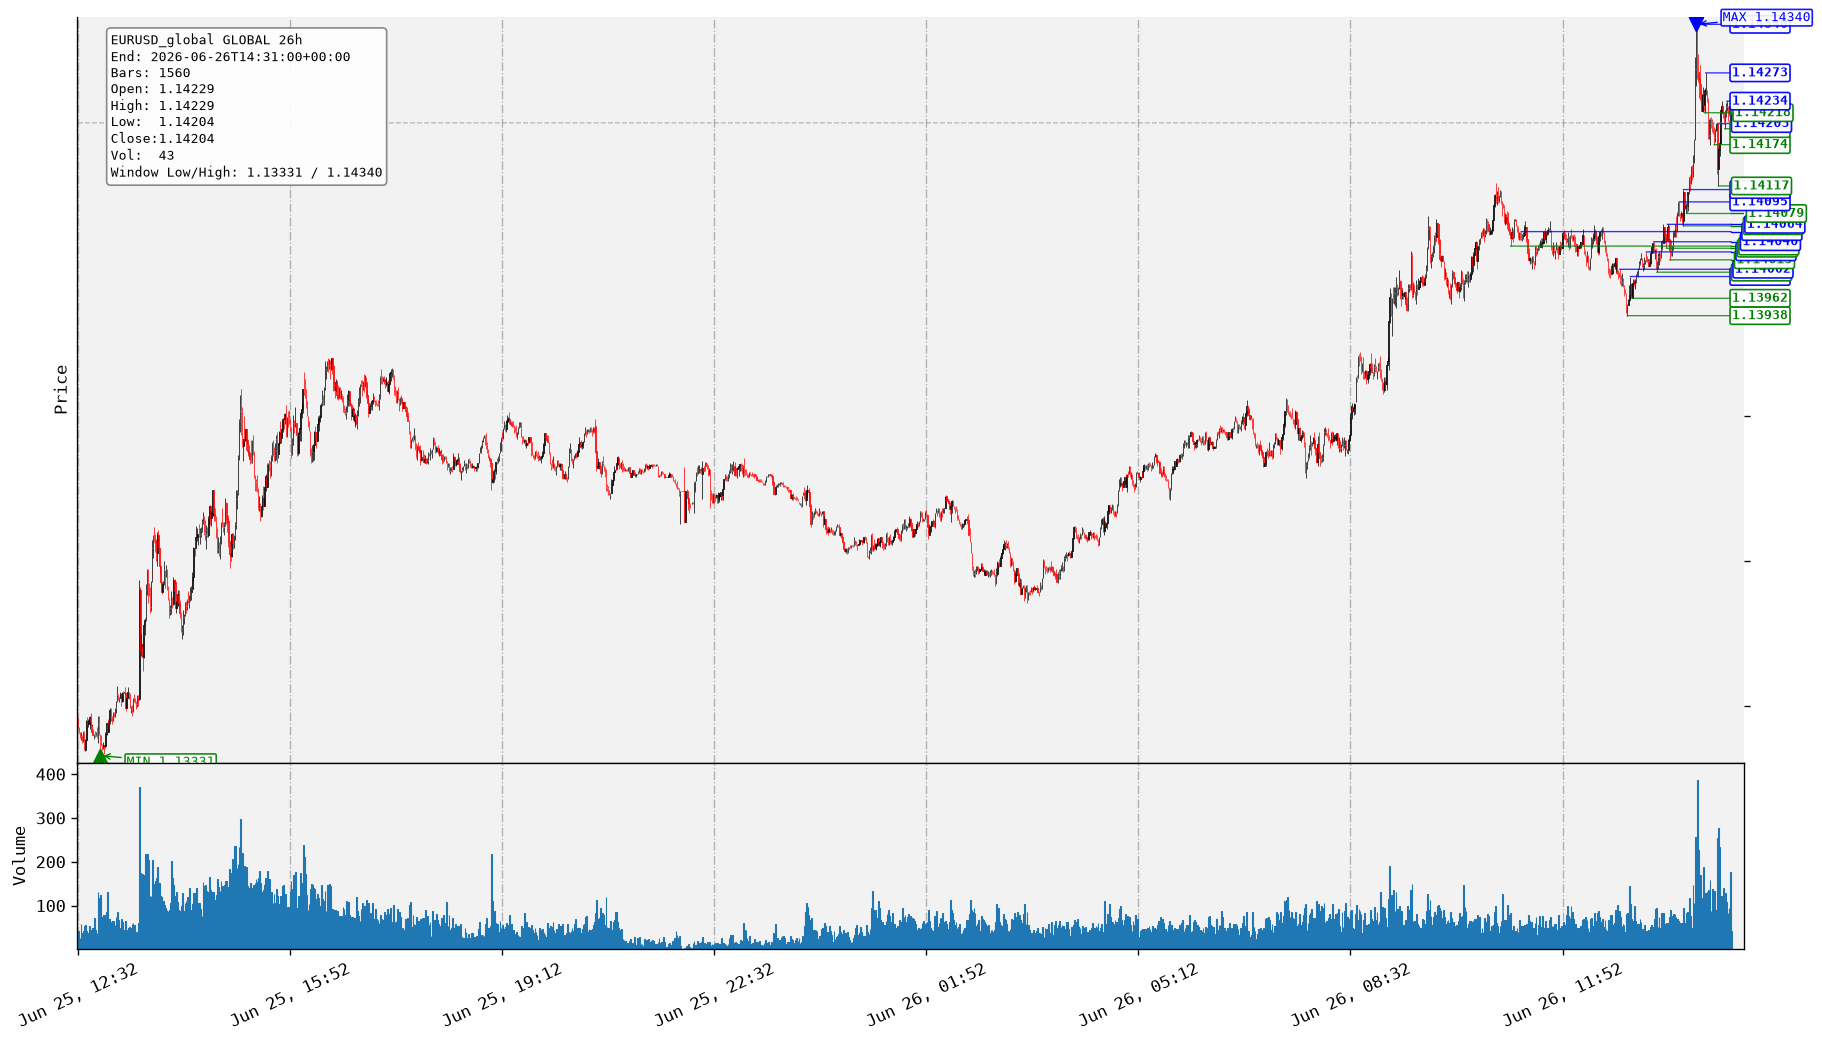

In [46]:
report, result, global_path, detail_path = process_symbol("EURUSD")
show_global_path(report, global_path, "EURUSD")

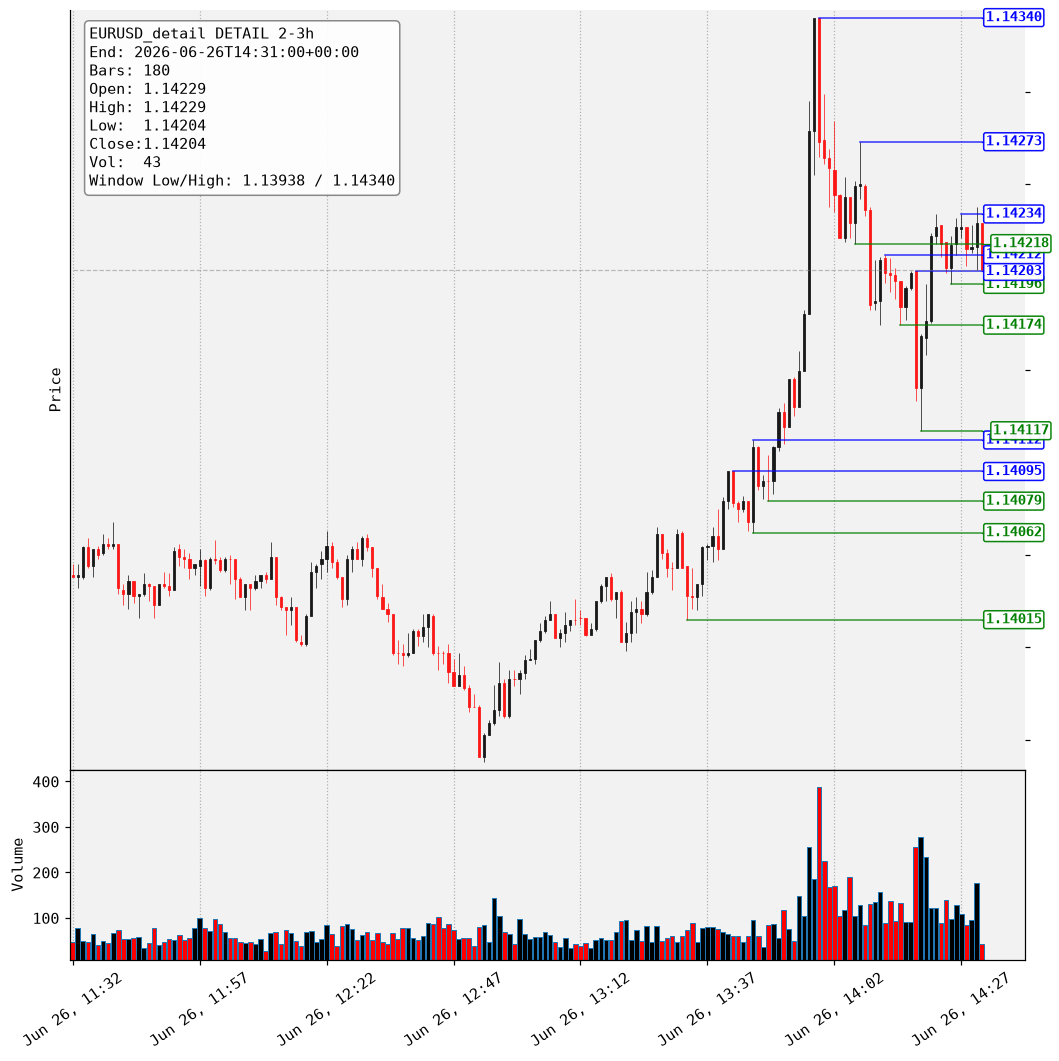

In [47]:
show_detail_path(report, detail_path, "EURUSD")

In [48]:
display(HTML(render_report_html(report, result)))